# Social Wasps: Routing Under Local Information
## Research-v3 / repeated feeding, all nests, all bouts

I study how worker movement rules affect the time and travel needed to give every
larva enough feeds to reach an explicit hunger threshold. The data supplies nest layouts and bout worker
counts; the simulation is a controlled synthetic experiment, not a reconstruction
of observed worker trajectories. This report covers v14, v72 and v87.

The source study is Sharma and Gadagkar's
[*Spatial organization of collective food distribution in a paper wasp society*](https://doi.org/10.1101/2023.10.13.562279).
Its observed bouts end at food exhaustion, while my synthetic round targets full
hunger-threshold coverage with unlimited feeding. Worker-to-worker food transfer
is not modeled. This is a proposed computational extension, not a reproduction
or a claim that these policies describe real wasps.

**Read the endpoint carefully:** `served` means remaining hunger is at most 0.12.
One feed may not be enough. I removed the original three-feed cap: feed count
alone never means full. The inherited growth and portion sizes remain model
assumptions, not calibrated physiology, food mass or measured biological satiation.
The first-feed v2 report is archived under the `research-v2-first-feed` Git tag.
The previous report is preserved in `final_analysis.ipynb` and the `legacy-v1` Git
tag. Its numerical rankings are not directly comparable with this revised model.


## 1. Reproducible Setup
The notebook imports the same engine used by the command-line benchmark and public
replays. Saved derived results allow readers to rerun the report without access to
the private datasets. Set `RERUN_EXPERIMENTS=True` only when the two CSV files are
available locally; this runs one worker and resumes compatible checkpoints.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, HTML, Markdown
from research_model import source_checksum, STRATEGIES
from research_report import generate_report, LABELS

RERUN_EXPERIMENTS = False
SCALE_FACTOR = 2
RANDOM_SEED = 42
FAIR_HORIZON = 3000
EXTENDED_HORIZON = 10000
REPLICATES = 10
if RERUN_EXPERIMENTS:
    from run_research import run_experiments
    run_experiments(REPLICATES)
report = json.loads(Path('research_results.json').read_text())
assert report['source_checksum'] == source_checksum(), 'Results are stale: rerun the benchmark.'
runs = pd.DataFrame(report['runs'])
fair = runs[runs.variant == 'main'].copy()
inventory = pd.DataFrame(report['inventory'])
scenarios = pd.DataFrame(report['scenarios'])
ranking = pd.DataFrame(report['ranking'])
display(inventory)


,nest,total_cells,base_larvae,empty_cells,pupae,scaled_larvae,grid_size
0,v14,114,34,65,9,68,22
1,v72,144,53,47,4,106,25
2,v87,158,67,50,37,134,28


## 2. What The Data Contributes
`ED_FL_3nests1noC2.csv` supplies cell positions, cell contents and stages.
`ALL_FL_minmaj_final3noC2.csv` supplies nest-bout records and worker counts. I keep
the existing event-code grouping (`FL`, `FL2`, `LPL`, `SPL`) for the worker-count rule;
without a validated codebook, these counts are **assumed activity proxies**, not
independent evidence of simulated feeding success.

Every observed nest-bout appears below using an anonymized ordinal scenario label.
Neither original worker identities nor raw CSV files are published. Bout counts
are 10 for v14, 14 for v72 and 12 for v87. These are three nests, not 36 independent
biological colonies.


In [2]:
display(scenarios)
if Path('ED_FL_3nests1noC2.csv').exists() and Path('ALL_FL_minmaj_final3noC2.csv').exists():
    from run_research import prepare
    observed_inventory, observed_scenarios, geometry = prepare()
    assert len(observed_scenarios) == len(scenarios) == 36
    print('Local private inputs agree with the public scenario inventory.')
else:
    print('Private data absent: report uses the published derived inventory and results.')


,public_id,nest,observed_rows,observed_feeding_events,observed_unique_cells,observed_unique_wasps,scaled_larvae,grid_size,n_wasps
0,v14-S01,v14,178,94,49,13,68,22,15
1,v14-S02,v14,27,12,10,11,68,22,15
2,v14-S03,v14,148,46,47,15,68,22,16
3,v14-S04,v14,188,89,48,11,68,22,15
4,v14-S05,v14,168,84,53,14,68,22,15
5,v14-S06,v14,19,1,1,14,68,22,15
6,v14-S07,v14,150,85,35,10,68,22,15
7,v14-S08,v14,97,41,45,12,68,22,15
8,v14-S09,v14,389,208,75,16,68,22,19
9,v14-S10,v14,164,66,45,15,68,22,16


Local private inputs agree with the public scenario inventory.


## 3. Synthetic Colony And Ground Rules
I duplicate each larva once to test a larger routing workload. Deterministic jitter
and collision-resolved grid placement preserve a recognizable layout, but the
additional larvae are synthetic and the quantized positions are not raw biological
coordinates. The grids are 22, 25 and 28 cells wide for v14, v72 and v87.

Initial hunger is drawn independently from stage ranges: L1 `[0.20,0.50]`, L2
`[0.45,0.75]`, L3 `[0.65,1.00]`. `FL_freq` never sets it. Before each tick, hungry
larvae gain L1 0.020, L2 0.028 or L3 0.035 hunger, capped at 1. Each feed subtracts
L1 0.35, L2 0.45 or L3 0.55, floored at 0. Once hunger reaches 0.12 or less, a larva
is full for this single round and stops recovering hunger. A new cycle is not modeled.
Replicate seeds vary initial hunger while every strategy inside a scenario-replicate
receives identical initial hunger, colony, staffing and scheduler seeds.

The retained resource formula is `max(ceil(larvae/5), observed workers) +
ceil(grouped activity events/100)`. All simulated workers can feed; food supply and
foraging trips are deliberately outside this experiment. Background cells are
traversable, not imaginary obstacles.


## 4. Agents And Fair Actions
A larva records first-feed time, every feed and hunger-threshold completion time.
A worker has one action per tick: one cardinal grid move, one feed, or one claim broadcast. Feeding and
broadcasting therefore replace movement rather than occurring for free.

Random activation uses a separate random stream from policy choices. The activation
permutations remain paired across strategies, so a strategy's extra random draws
cannot change the scheduler. A run stops when all larvae reach the hunger threshold or its
horizon. Timeout is recorded as `completion_step=None`, never as a completed run.


In [3]:
policy_table = pd.DataFrame([
    ('random', 'Blind', 'Independent cardinal walk'),
    ('biased', 'Blind', 'Persistent direction; 25% chance to redraw'),
    ('greedy', 'Global', 'Random target weighted by remaining hunger / (1 + distance)'),
    ('tsp', 'Global', 'Nearest-neighbour tour; historical alias, not optimal TSP'),
    ('local_nearest', 'Local', 'Observed / remembered nearest target; exploration otherwise'),
    ('local_urgency_claims', 'Local', 'Observed remaining hunger / (1 + distance), with expiring local claims')
], columns=['strategy', 'information', 'rule'])
display(policy_table)


,strategy,information,rule
0,random,Blind,Independent cardinal walk
1,biased,Blind,Persistent direction; 25% chance to redraw
2,greedy,Global,Random target weighted by remaining hunger / (...
3,tsp,Global,"Nearest-neighbour tour; historical alias, not ..."
4,local_nearest,Local,Observed / remembered nearest target; explorat...
5,local_urgency_claims,Local,"Observed remaining hunger / (1 + distance), wi..."


Local policies sense Manhattan radius 3 and keep at most 256 observed records.
The urgency policy exchanges claims only with workers within radius 3; leases last
8 ticks and renewal is considered every 4 ticks. Lower worker IDs resolve received
claim conflicts. A remembered location and priority come from an actual observation,
not an unseen global lookup. Global and blind policies remain useful baselines,
but differences between information classes cannot be attributed to routing alone.


## 5. Full Benchmark And Ablations
The common-horizon experiment runs 36 scenarios x 10 paired replicates x 6 policies
= **2160 fair simulations**. Two additional urgency configurations (claims off and
global sensing on) add **720 ablation simulations**. Extended runs, when needed,
are kept separate from the fair ranking.

Ranking sorts completion reliability first, then median horizon-capped time, then
movement per served larva. It is a declared engineering ranking, not a statistical
claim about all wasp colonies. Every numerical table below comes from the executed
JSON artifact, not manually typed results.


In [4]:
display(ranking)
display(fair.groupby(['nest', 'strategy']).agg(
    runs=('finished', 'size'), reliability=('finished', 'mean'),
    median_capped_ticks=('observed_steps', 'median'),
    median_travel_per_served=('distance_per_served', 'median')).round(3))
display(runs)
extended = pd.DataFrame(report['extended'])
display(extended if not extended.empty else pd.DataFrame({'extended_pass': ['Not needed: all fair runs completed']}))

# Pair the same scenario and seed; an aggregate median can hide policy reversals.
paired = fair.pivot(index=['scenario', 'replicate'], columns='strategy', values='observed_steps')
delta = paired['local_urgency_claims'] - paired['local_nearest']
display(pd.DataFrame([{'comparison': 'Urgency + claims vs local nearest',
    'faster': int((delta < 0).sum()), 'tied': int((delta == 0).sum()),
    'slower': int((delta > 0).sum()), 'median_paired_tick_difference': delta.median()}]))


,strategy,runs,reliability,median_capped_steps,median_distance_per_served,median_priority_wait
0,local_urgency_claims,360,1.0,74.0,10.588235,29.791026
1,local_nearest,360,1.0,79.0,15.040927,28.362110
2,tsp,360,1.0,173.5,34.697761,72.804218
3,greedy,360,1.0,208.0,42.686426,99.804367
4,biased,360,1.0,278.5,46.759434,53.795121
5,random,360,1.0,389.5,79.601169,83.276277


runs  reliability  median_capped_ticks  \
nest strategy                                                       
v14  biased                 100          1.0                304.0   
     greedy                 100          1.0                112.5   
     local_nearest          100          1.0                 63.0   
     local_urgency_claims   100          1.0                 57.0   
     random                 100          1.0                335.5   
     tsp                    100          1.0                 92.5   
v72  biased                 140          1.0                270.0   
     greedy                 140          1.0                206.5   
     local_nearest          140          1.0                 77.5   
     local_urgency_claims   140          1.0                 77.5   
     random                 140          1.0                386.5   
     tsp                    140          1.0                157.0   
v87  biased                 120          1.0                281.0   
     greedy                 120          1.0                236.5   
     local_nearest          120          1.0                 89.0   
     local_urgency_claims   120          1.0                 77.0   
     random                 120          1.0                429.0   
     tsp                    120          1.0                181.0   

                           median_travel_per_served  
nest strategy                                        
v14  biased                                  50.956  
     greedy                                  23.316  
     local_nearest                           12.051  
     local_urgency_claims                     7.632  
     random                                  70.993  
     tsp                                     18.375  
v72  biased                                  44.755  
     greedy                                  42.844  
     local_nearest                           14.958  
     local_urgency_claims                    11.448  
     random                                  79.542  
     tsp                                     32.458  
v87  biased                                  46.567  
     greedy                                  48.522  
     local_nearest                           16.817  
     local_urgency_claims                    11.067  
     random                                  88.507  
     tsp                                     36.989

,model_version,strategy,seed,finished,completion_step,observed_steps,stop_reason,fed_larvae,total_larvae,completion_rate,...,priority_weighted_wait,total_feeds,final_avg_hunger,messages,n_wasps,grid_size,scenario,nest,replicate,variant
0,research-v3,random,204469,True,262,262,complete,68,68,1.0,...,57.099974,169,0.005150,0,15,22,v14-S01,v14,0,main
1,research-v3,biased,204469,True,367,367,complete,68,68,1.0,...,42.760577,164,0.002383,0,15,22,v14-S01,v14,0,main
2,research-v3,greedy,204469,True,111,111,complete,68,68,1.0,...,53.531573,174,0.002463,0,15,22,v14-S01,v14,0,main
3,research-v3,tsp,204469,True,84,84,complete,68,68,1.0,...,34.881016,157,0.017339,0,15,22,v14-S01,v14,0,main
4,research-v3,local_nearest,204469,True,62,62,complete,68,68,1.0,...,19.873113,153,0.012831,0,15,22,v14-S01,v14,0,main
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,research-v3,tsp,166461,True,176,176,complete,134,134,1.0,...,76.968593,309,0.030645,0,29,28,v87-S12,v87,9,main
2876,research-v3,local_nearest,166461,True,73,73,complete,134,134,1.0,...,33.309167,314,0.019561,0,29,28,v87-S12,v87,9,main
2877,research-v3,local_urgency_claims,166461,True,113,113,complete,134,134,1.0,...,37.326623,338,0.004535,476,29,28,v87-S12,v87,9,main
2878,research-v3,local_urgency_claims,166461,True,87,87,complete,134,134,1.0,...,32.421404,320,0.019918,0,29,28,v87-S12,v87,9,no_claims


,extended_pass
0,Not needed: all fair runs completed


,comparison,faster,tied,slower,median_paired_tick_difference
0,Urgency + claims vs local nearest,215,8,137,-4.5


## 6. Playable Simulations
Visualization is useful because the same aggregate score can hide repeated visits,
crowded cells and delayed larvae. The lab plays recorded Python states, never a
different browser simulation. It includes a median tour example for each nest and
the slowest main-run example; selection is deterministic and not cherry-picked to
make the new policy win.

The four original methods remain individually playable below. In the lab, select
**Compare four** to see them synchronized by actual tick; a finished method holds
its last frame. GitHub sanitizes notebook iframe/JavaScript outputs, so use the
linked live lab for playback. Local Jupyter permits the interactive embeds.


### tsp: recorded hunger-based feeding round
[Open interactive replay](https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=tsp)

In [5]:
display(HTML('<iframe title="tsp hunger-based replay" src="https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=tsp" width="100%" height="780" loading="lazy" style="border:1px solid #ccc"></iframe>'))

C:\Users\Hemu\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### biased: recorded hunger-based feeding round
[Open interactive replay](https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=biased)

In [6]:
display(HTML('<iframe title="biased hunger-based replay" src="https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=biased" width="100%" height="780" loading="lazy" style="border:1px solid #ccc"></iframe>'))

### random: recorded hunger-based feeding round
[Open interactive replay](https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=random)

In [7]:
display(HTML('<iframe title="random hunger-based replay" src="https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=random" width="100%" height="780" loading="lazy" style="border:1px solid #ccc"></iframe>'))

### greedy: recorded hunger-based feeding round
[Open interactive replay](https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=greedy)

In [8]:
display(HTML('<iframe title="greedy hunger-based replay" src="https://hemu77.github.io/Bio-Inspired-Routing-Optimization-in-Social-Wasps/?scenario=v87-S03&strategy=greedy" width="100%" height="780" loading="lazy" style="border:1px solid #ccc"></iframe>'))

## 7. Six Analysis Questions
These plots replace the unsupported composite difficulty score and redundant
four-point frontier. The coverage band summarizes replicate-level means across
the same scenarios; it is conditional stochastic variability, not a population
confidence interval. Waiting measures are explicitly restricted when censored.


In [9]:
captions = generate_report(report)
assert len(captions) == 6

### 7.1. How quickly does each policy reach the whole colony?

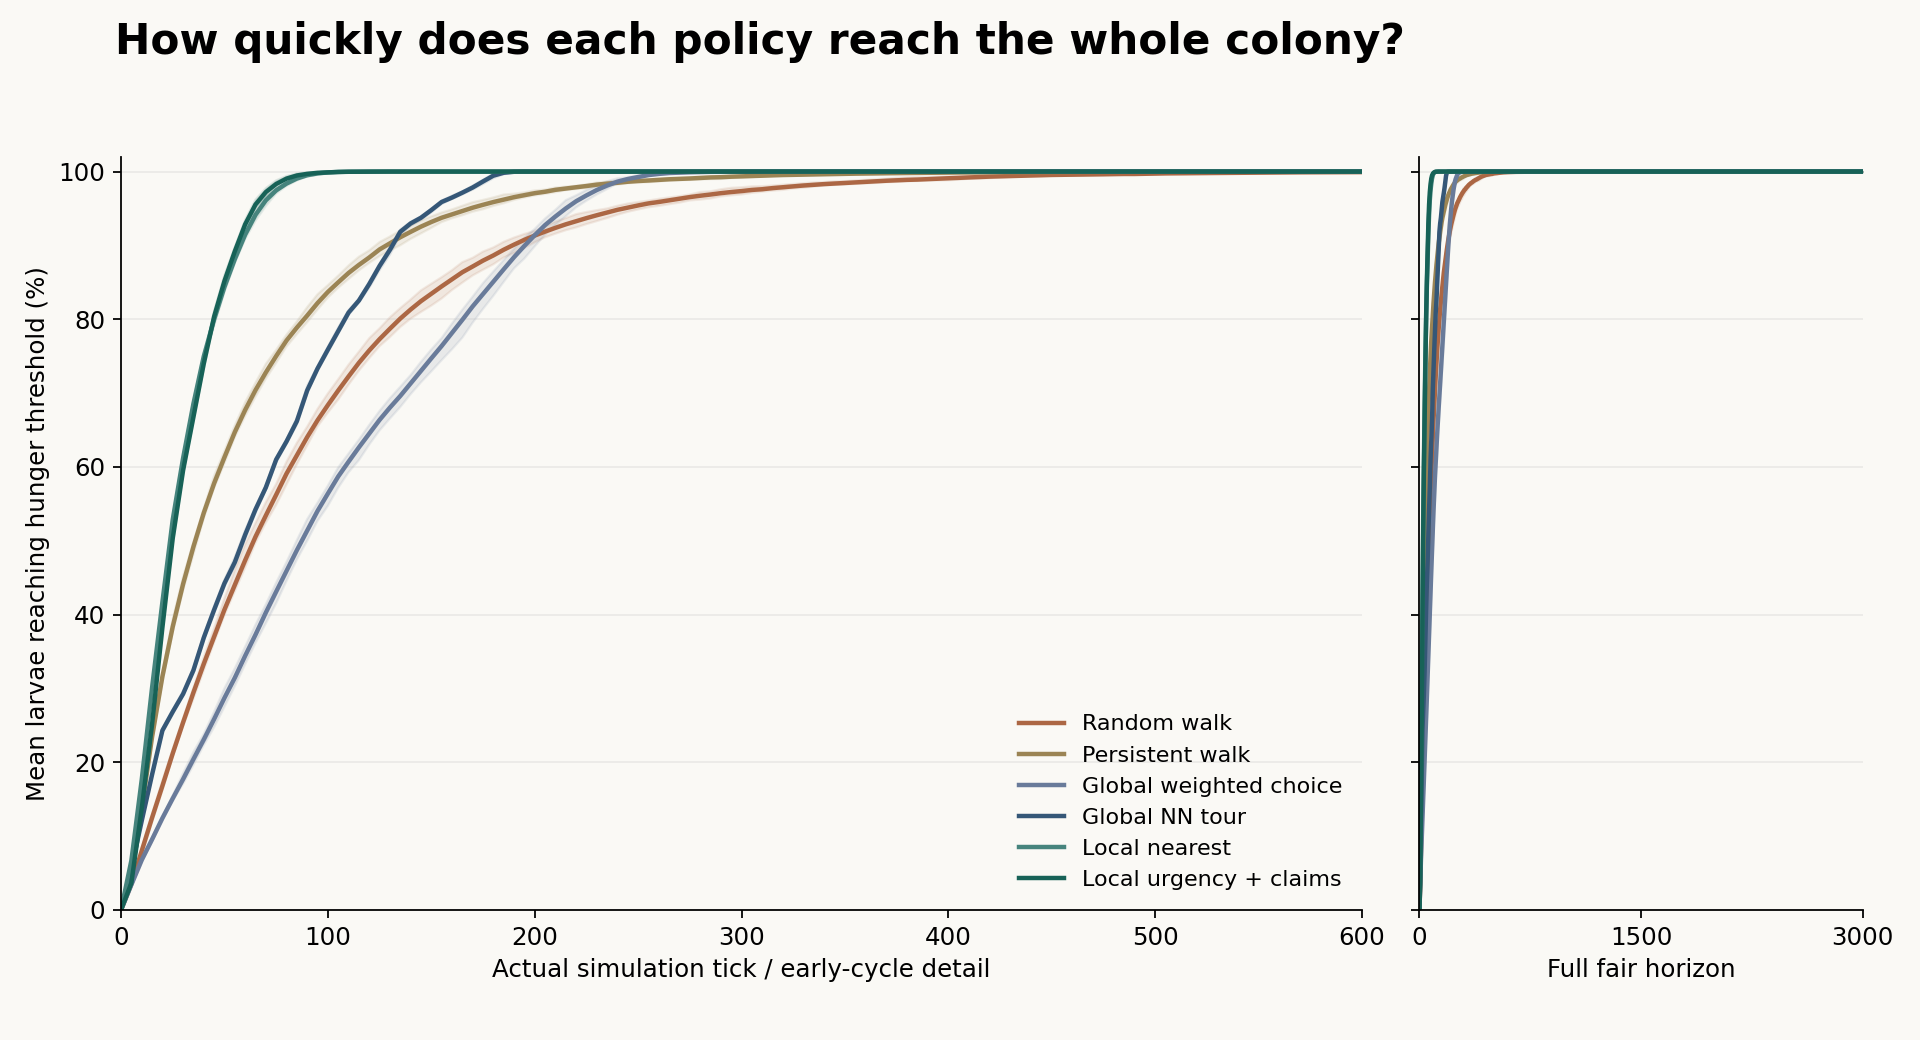

In [10]:
display(Image(filename='figures/research-v3/01_coverage.png'))

In [11]:
display(Markdown(captions[0]['interpretation']))

Each line averages all 36 scenarios; shading is the 10th-90th percentile of ten replicate-level means, not a biological confidence interval. Finished runs hold at 100% through tick 3000. Local urgency + claims ranks first by reliability, then median capped time, then movement per served larva; the local/global information distinction prevents a causal claim about routing alone.

### 7.2. All policies finish; completion speed still differs

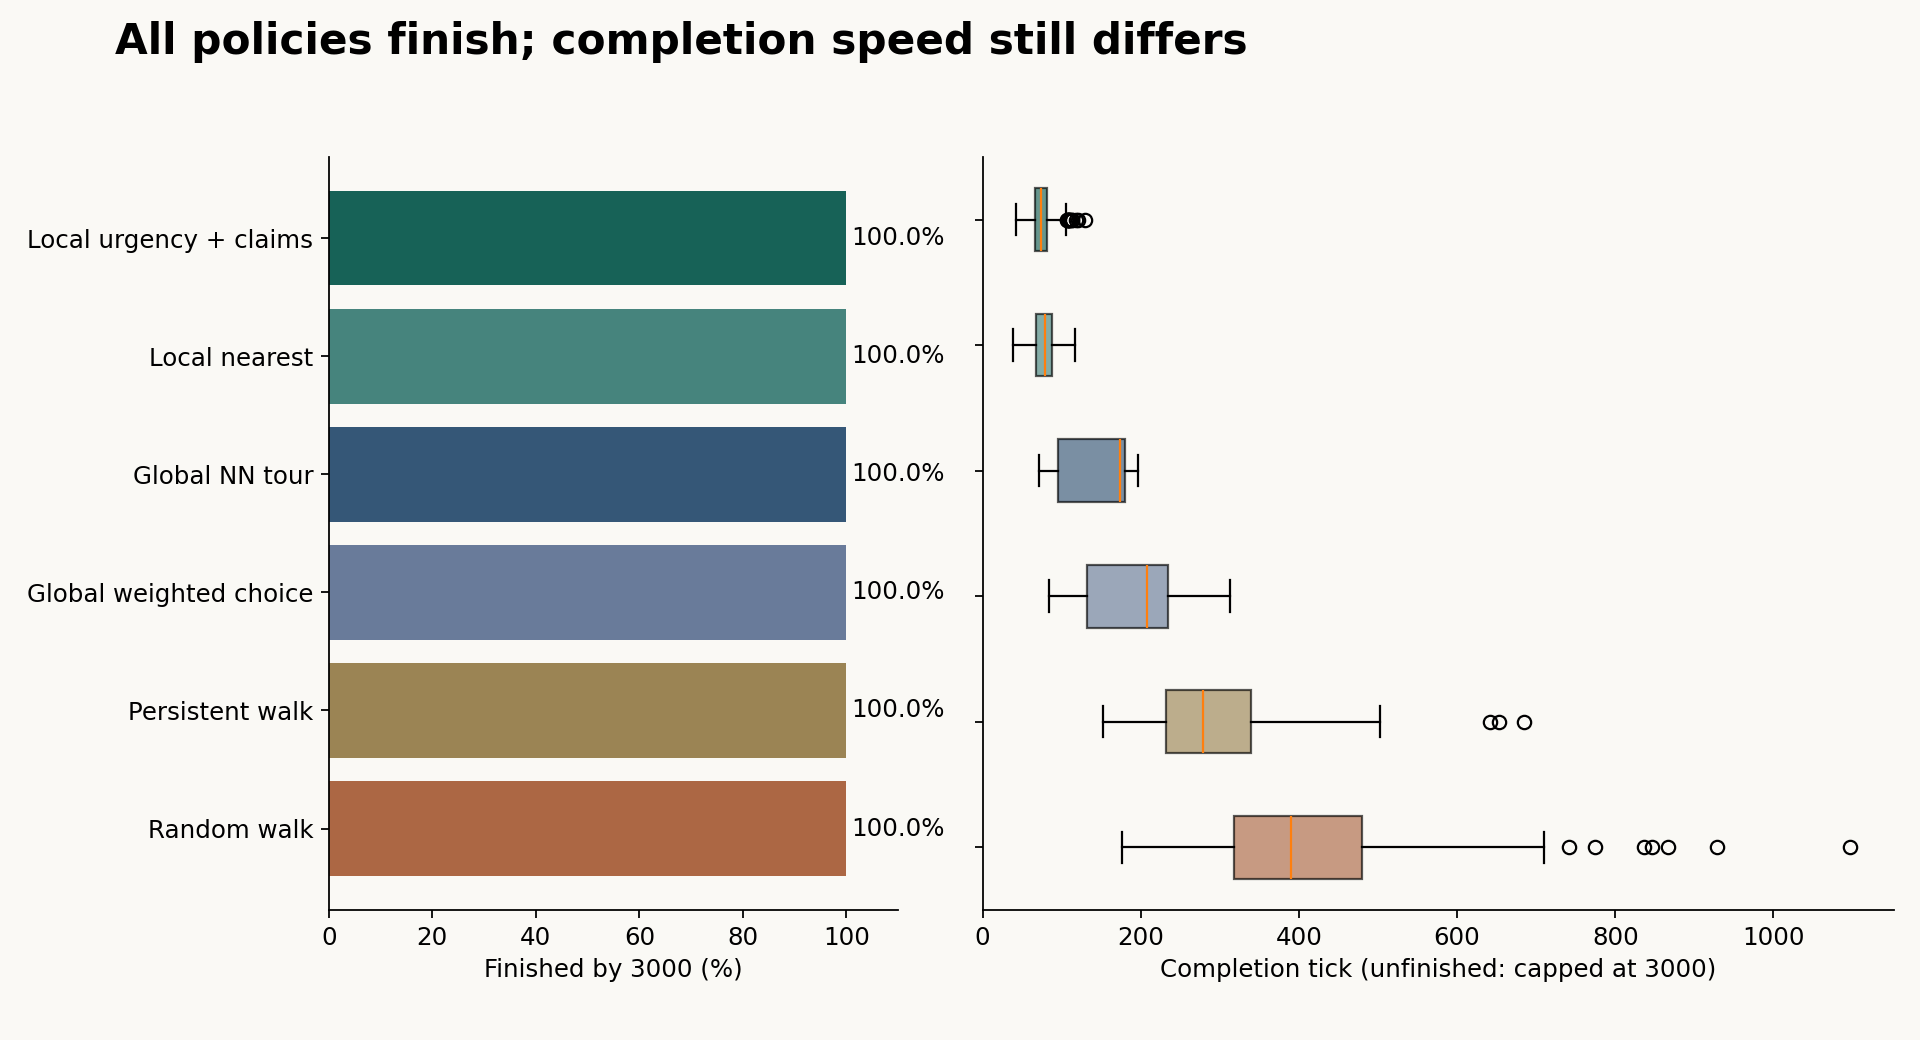

In [12]:
display(Image(filename='figures/research-v3/02_reliability.png'))

In [13]:
display(Markdown(captions[1]['interpretation']))

The left panel reports completion frequency over 360 runs per strategy. The right includes every run: an unfinished run contributes the fair horizon, never a fabricated completion tick. This is horizon-capped time, not an estimate of uncensored completion time; medians alone can hide the slow tail.

### 7.3. How much movement buys one fully served larva?

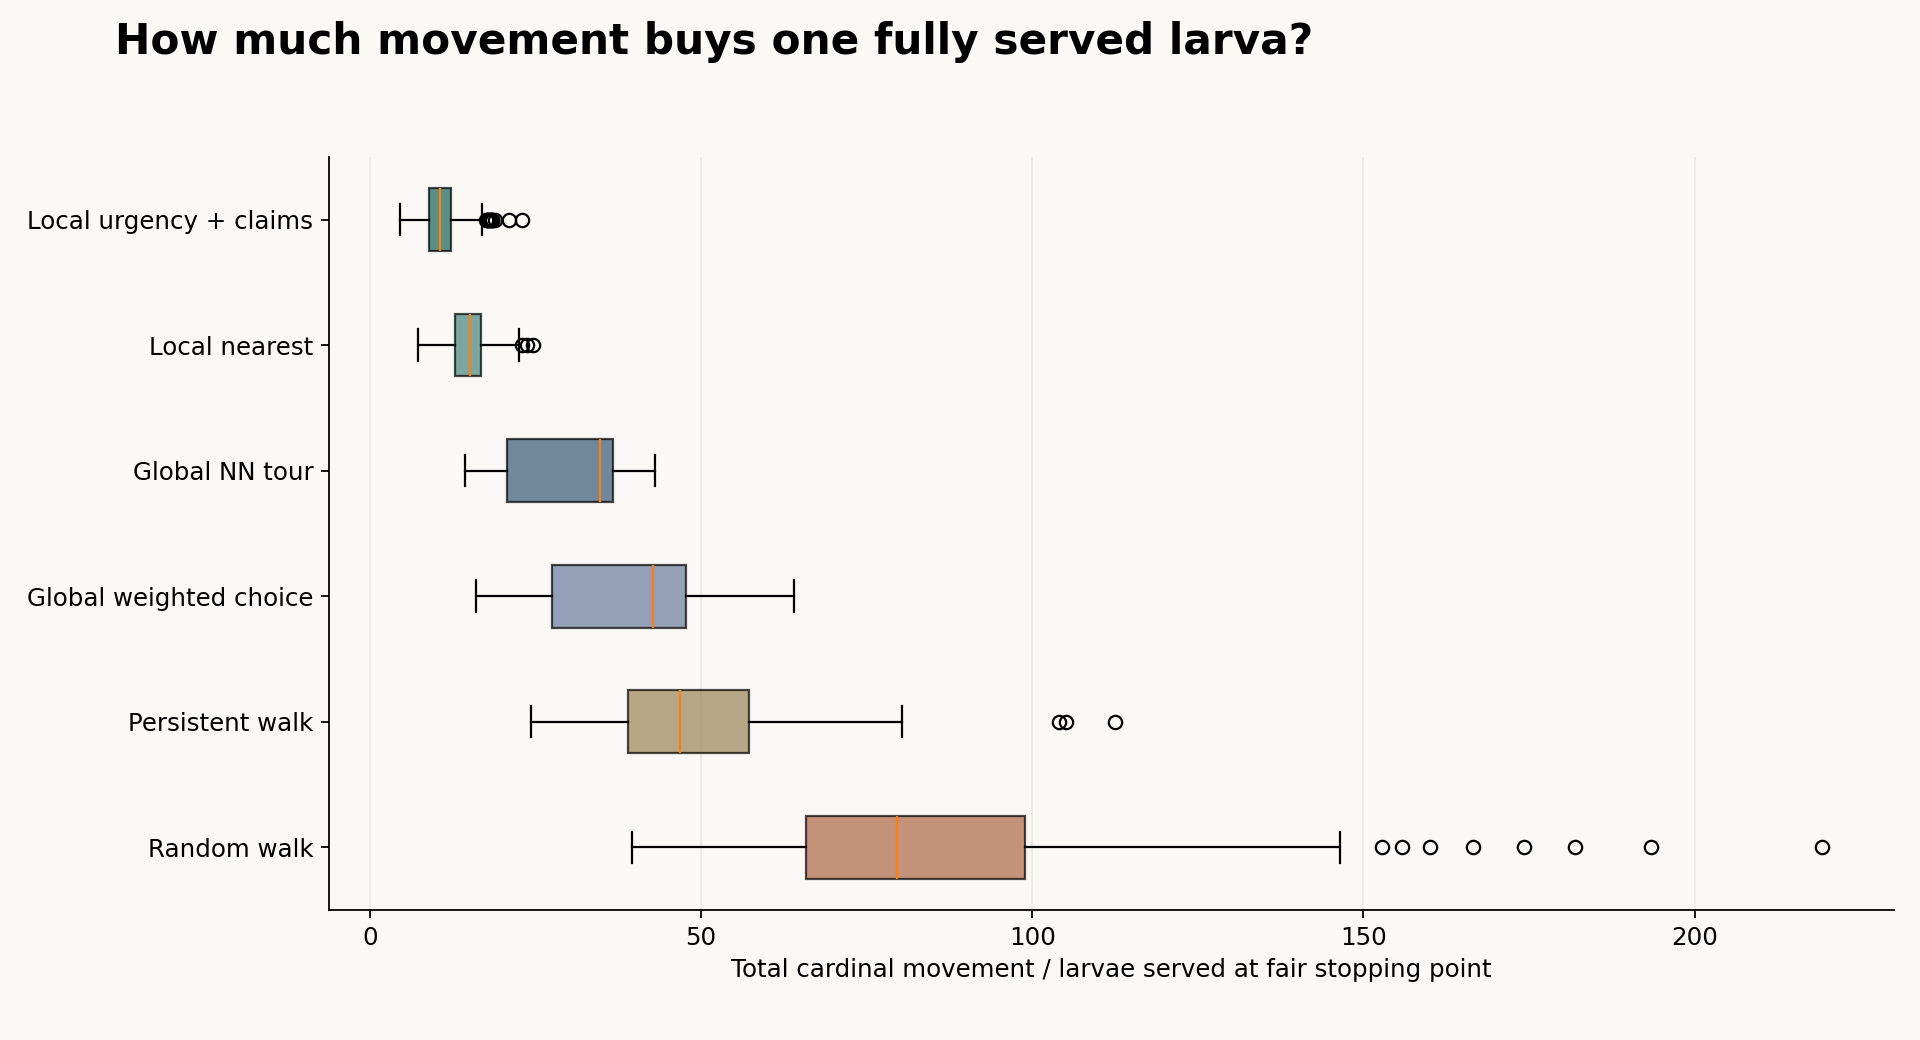

In [14]:
display(Image(filename='figures/research-v3/03_movement.png'))

In [15]:
display(Markdown(captions[2]['interpretation']))

Lower values mean less grid travel per served larva. Boxplots show all scenario-replicate runs rather than just four aggregate points. Read this with the reliability panel: a policy that serves fewer larvae is not automatically preferable because it moves less; distance is a computational proxy, not measured metabolic energy.

### 7.4. Does efficient routing leave larvae waiting?

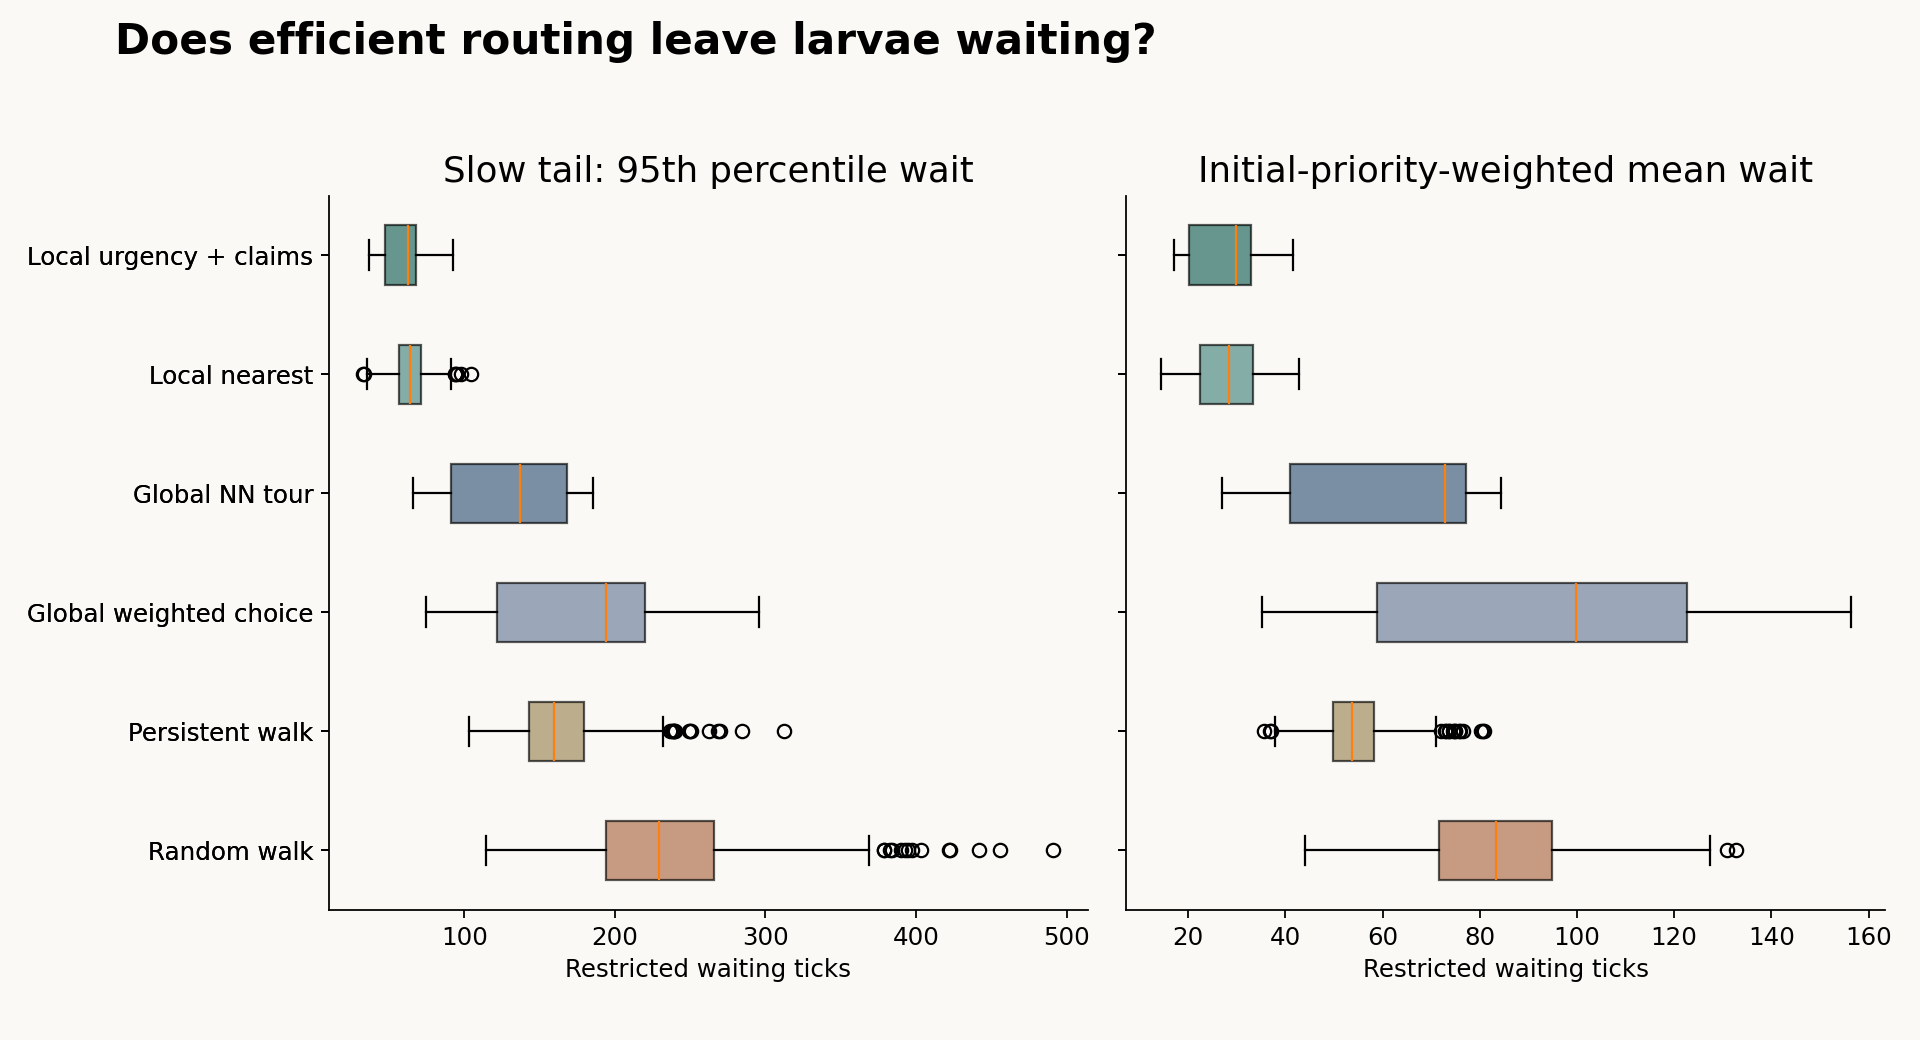

In [16]:
display(Image(filename='figures/research-v3/04_waiting.png'))

In [17]:
display(Markdown(captions[3]['interpretation']))

Each larva's wait starts at tick zero and ends when its remaining hunger reaches 0.12 or less; unfinished larvae are censored at 3000. The left measures the long-waiting tail, while the right weights waits by randomly assigned initial hunger, not terminal hunger. These are model-threshold waiting metrics, not evidence of physiological starvation or measured welfare.

### 7.5. Does the result survive every nest and bout?

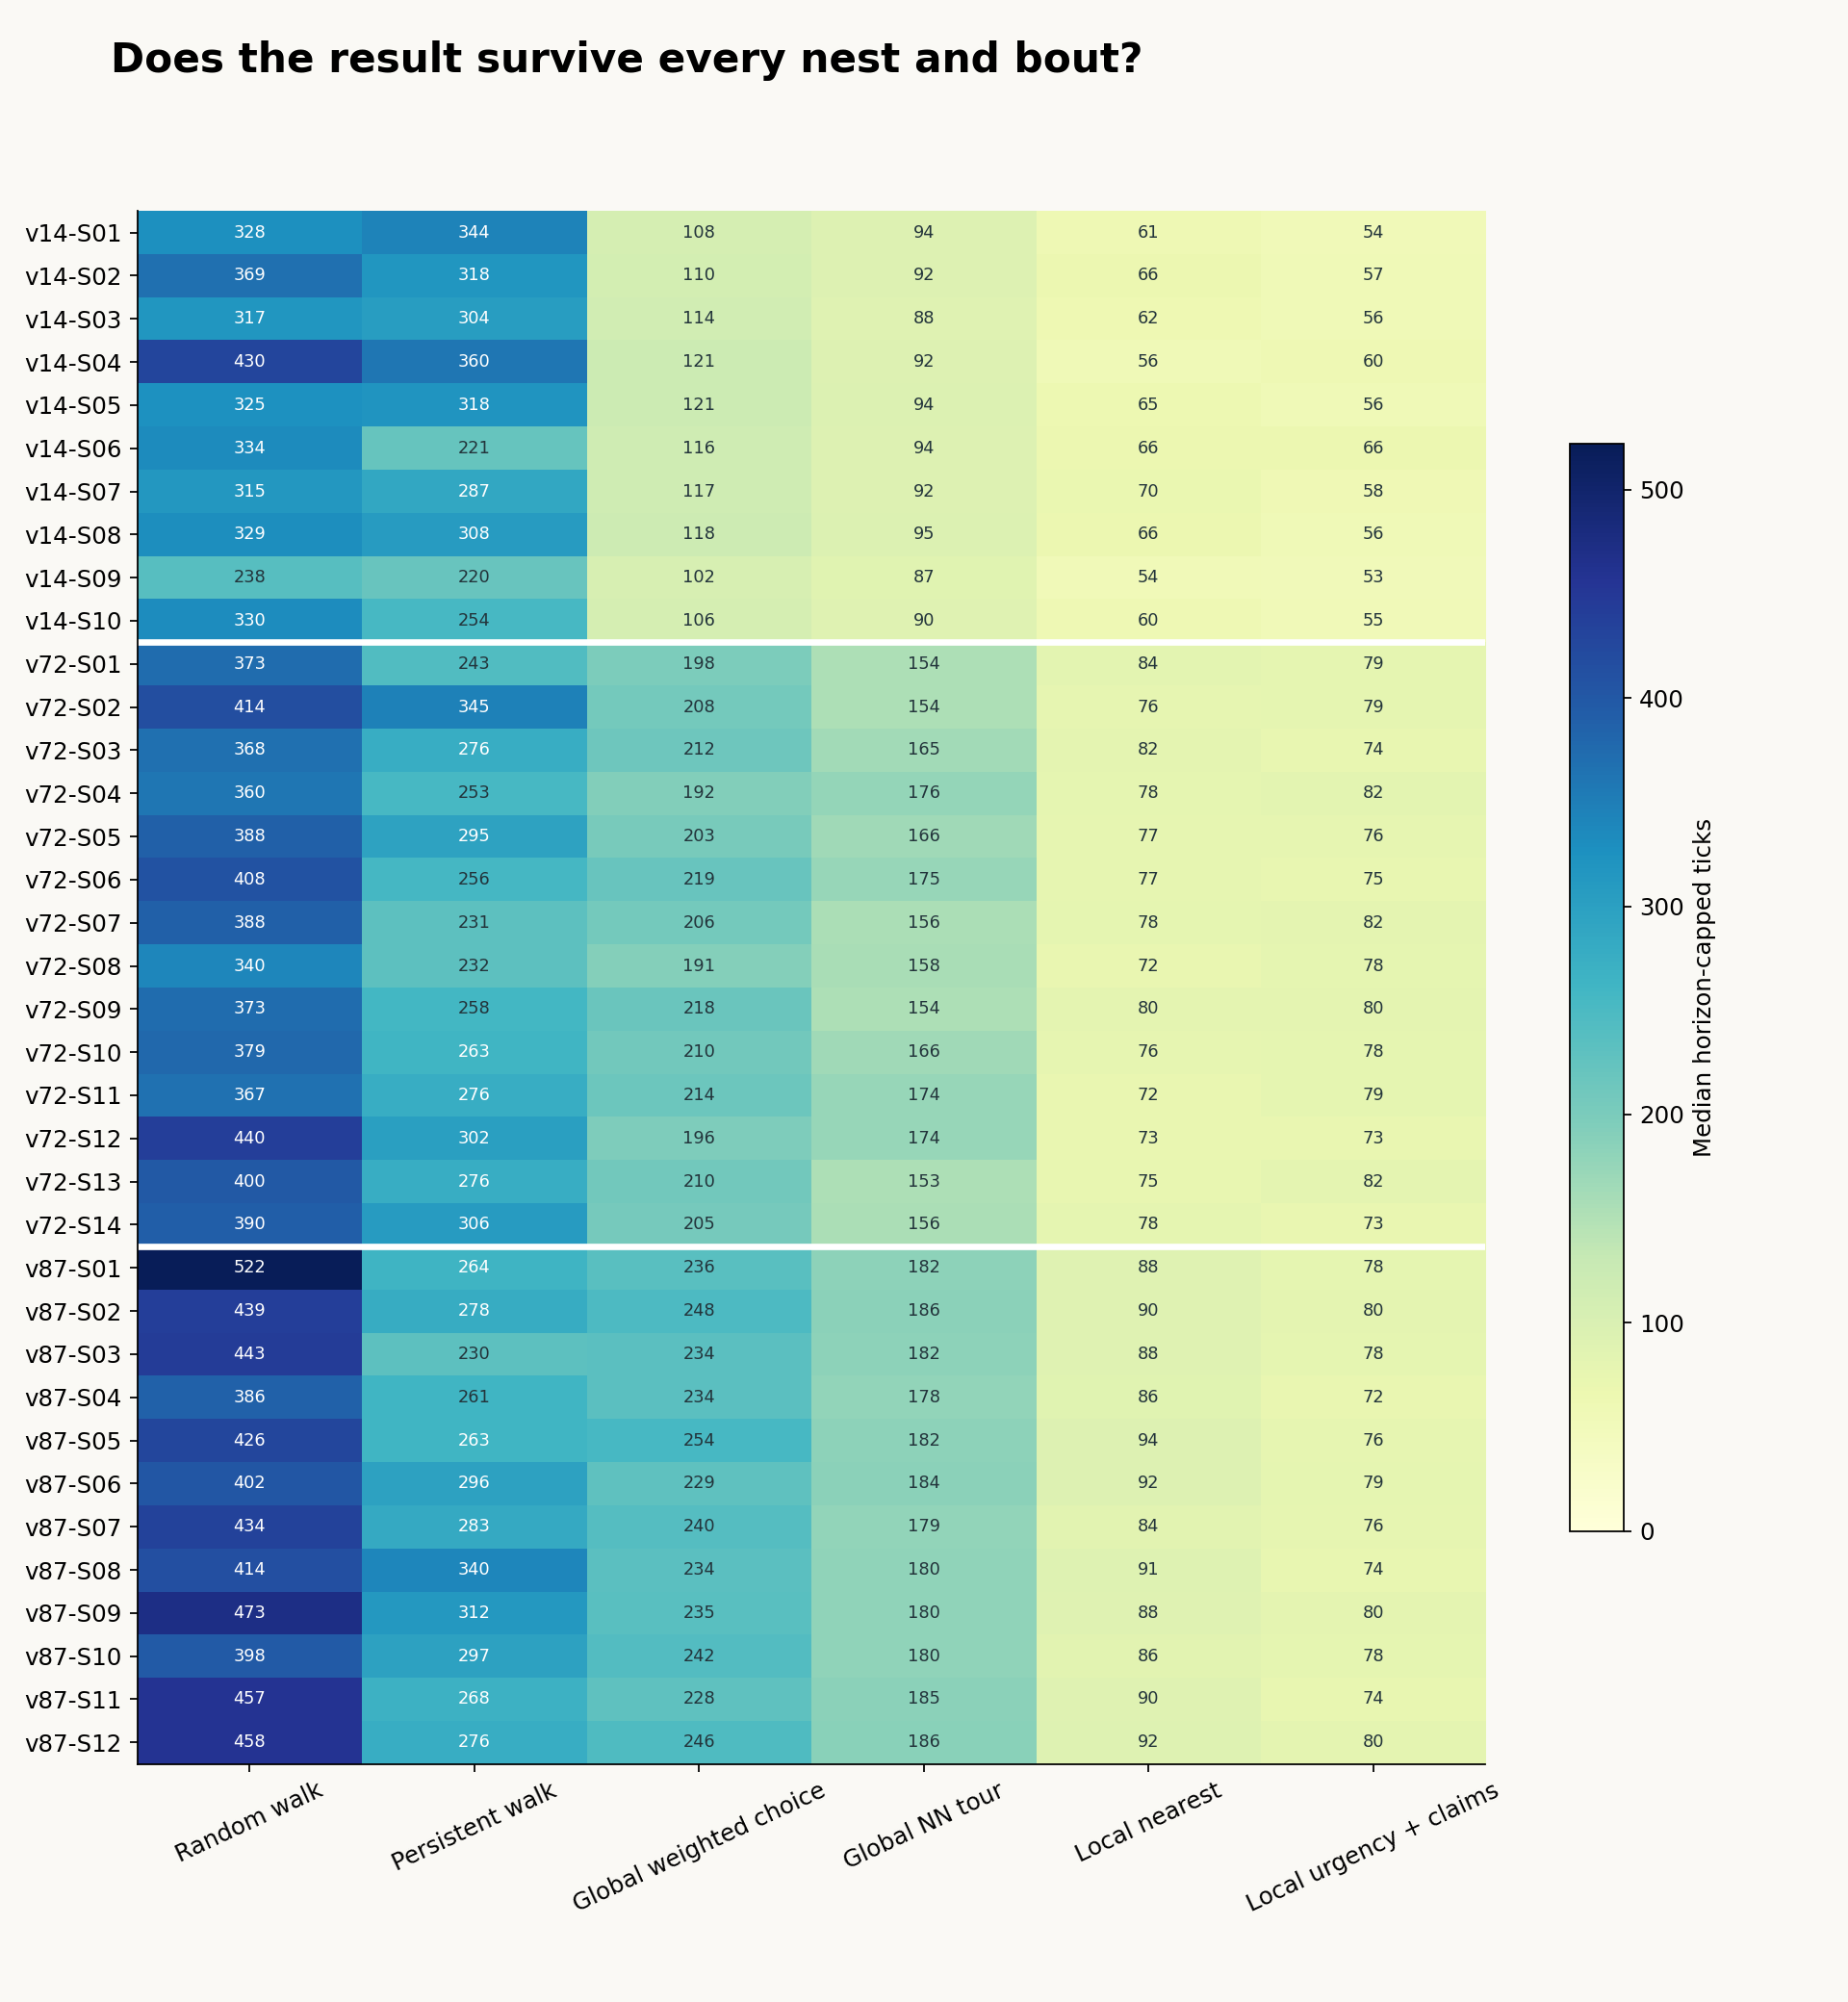

In [18]:
display(Image(filename='figures/research-v3/05_scenarios.png'))

In [19]:
display(Markdown(captions[4]['interpretation']))

Rows retain all 36 scenarios, grouped into v14, v72 and v87; columns use one shared color scale. Numbers are medians over ten matched replicates, and an asterisk indicates at least one unfinished run. These scenarios reuse a nest's synthetic layout and differ in worker resources and seeds; they are not 36 independent biological colonies.

### 7.6. Is communication worth its action cost?

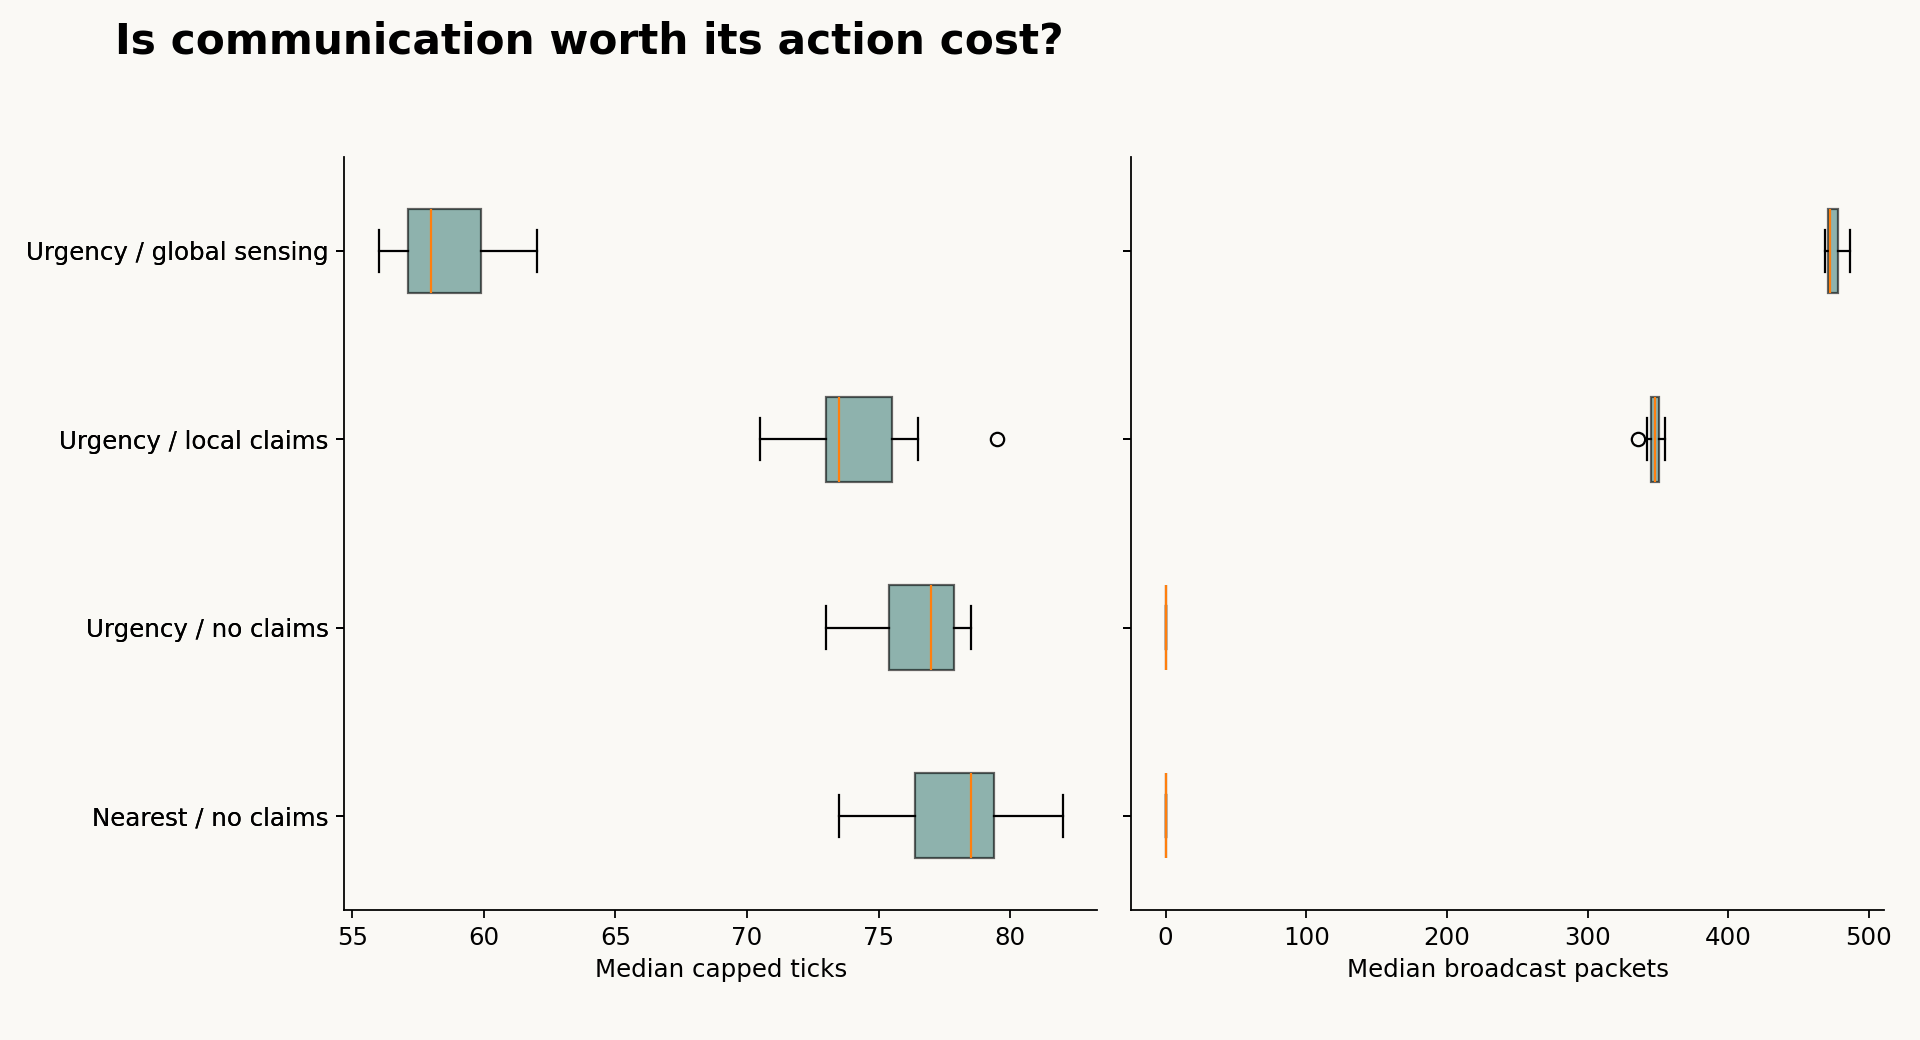

In [20]:
display(Image(filename='figures/research-v3/06_coordination.png'))

In [21]:
display(Markdown(captions[5]['interpretation']))

The same 36 scenarios and ten seeds are paired across all four configurations; each box summarizes ten replicate-level medians. Claim broadcasts consume a tick instead of movement or feeding, and packets count separately from distance. Local claims have median capped time 74 versus 76 without claims; this result is reported even if coordination is slower. The global-sensing ablation changes information access, not the observed nest geometry.

## 8. Conclusions And Limits
Read the newly executed ranking rather than transferring conclusions from v2.
Explicit communication cost matters: claims are not automatically an improvement.
The ablation helps separate the effect of hunger prioritization, coordination
and information access rather than calling a visually appealing policy 'best'.
The paired table also shows losses and ties: a lower overall median is not a
universal win. Claims-off comparisons isolate claims within the urgency policy;
comparing local nearest with urgency-plus-claims changes both mechanisms.

The source study discusses possible redundancy benefits of repeated and
overlapping feeding. Expiring claims are a counterfactual mechanism, not an
observed wasp signal. A useful extension would test efficiency versus robustness
under limited food and worker failure; those tests are not in this report.

Only three real nest layouts are available; doubling larvae is synthetic. The
random priorities are assumed rather than measured. Worker resource counts are
derived from activity summaries, not calibrated trajectories. There is no validated
physiology, food depot, collision avoidance, continuous flight model or 3D geometry.
Future work should use a confirmed event codebook, measured feeding timestamps,
broader nest samples and a prespecified sensitivity analysis before biological
conclusions are made.


## 9. Validation Gate
This cell checks counts, matched configurations and source provenance. The public synthetic suite also checks actions, local sensing, scheduler independence and replay consistency.

In [22]:
from validate_research import validate_all
evidence = validate_all()
display(pd.DataFrame([evidence]))
assert len(scenarios) == 36 and len(fair) == 2160
assert len(runs) == 2880 and len(runs[runs.variant != 'main']) == 720
assert set(fair.nest) == {'v14', 'v72', 'v87'}
assert (fair.groupby(['scenario', 'replicate'])[['seed','n_wasps','grid_size','total_larvae']].nunique() == 1).all().all()
print('Nests:', fair.nest.nunique(), '| scenarios:', fair.scenario.nunique())
print('Fair simulations:', len(fair), '| ablations:', len(runs)-len(fair), '| extended:', len(extended))
print('Best ranked strategy:', ranking.iloc[0].strategy, '| still incomplete:', int((~fair.finished).sum()))
print('GREEN: all validation checks passed. Read the limitations before interpreting results.')


,nests,scenarios,fair_runs,ablations,replays,extended_runs,incomplete_fair,source_verified
0,3,36,2160,720,24,0,0,True


Nests: 3 | scenarios: 36
Fair simulations: 2160 | ablations: 720 | extended: 0
Best ranked strategy: local_urgency_claims | still incomplete: 0
GREEN: all validation checks passed. Read the limitations before interpreting results.
